# TradingView's PineScript strategy conversion example

This is a modified version of the main example.

- Use 90% of capital for every position and pray that the stop losses work

See README for more details.

### Github notebook rendering issues

**If you are viewing this file on Github**: The current Github online notebook viewer cannot render the interactive Plotly charts used in this notebook.
To view the charts, you need to download run the notebook locally.

## Set up

Set up the parameters used in in this strategy backtest study.

- Backtested blockchain, exchange and trading pair
- Backtesting period
- Strategy parameters for technical indicators

In [2]:
import datetime

from tradingstrategy.chain import ChainId
from tradingstrategy.timebucket import TimeBucket
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.strategy_module import TradeRouting, ReserveCurrency

#
# Strategy properties
# 

# How our trades are routed.
TRADE_ROUTING = TradeRouting.trader_joe_usdc

# How often the strategy performs the decide_trades cycle.
TRADING_STRATEGY_CYCLE = CycleDuration.cycle_4h

# Time bucket for our candles
CANDLE_TIME_BUCKET = TimeBucket.h4

# Candle time granularity we use to trigger stop loss checks
STOP_LOSS_TIME_BUCKET = TimeBucket.m15

# Strategy keeps its cash in USDC
RESERVE_CURRENCY = ReserveCurrency.usdc

# Which trading pair we are backtesting on
# (Might be different from the live trading pair)
# https://tradingstrategy.ai/trading-view/polygon/quickswap/eth-usdc
TRADING_PAIR = (ChainId.avalanche, "trader-joe", "WAVAX", "USDC")

# How much % of the cash to put on a single trade
POSITION_SIZE = 0.90

# Start with this amount of USD
INITIAL_DEPOSIT = 5_000

#
# Strategy inputs
#

# How many candles we load in the decide_trades() function for calculating indicators
LOOKBACK_WINDOW = 90

# How many candles we use to calculate the Relative Strength Indicator
RSI_LENGTH = 14

# RSI must be above this value to open a new position.
RSI_THRESHOLD = 65

# What's the moving average length in candles for Bollinger bands
MOVING_AVERAGE_LENGTH = 20

# Bollinger band's standard deviation
STDDEV = 2.0

# Backtest range
#
# Note that for this example notebook we deliberately choose a very short period,
# as the backtest completes faster, charts are more readable
# and tables shorter for the demostration.
#
START_AT = datetime.datetime(2022, 3, 1)

# Backtest range
END_AT = datetime.datetime(2022, 10, 1)

# Stop loss relative to the mid price during the time when the position is opened
#
# If the price drops below this level, trigger a stop loss
STOP_LOSS_PCT = 0.98


## Strategy logic and trade decisions

- `decide_trades` function decide what trades to take.
- See README for explanations on technical indicators used


In [3]:
from typing import List, Dict

import pandas as pd
from pandas_ta import bbands
from pandas_ta.overlap import ema
from pandas_ta.momentum import rsi

from tradingstrategy.universe import Universe

from tradeexecutor.state.visualisation import PlotKind
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.pricing_model import PricingModel
from tradeexecutor.strategy.pandas_trader.position_manager import PositionManager
from tradeexecutor.state.state import State
from tradeexecutor.strategy.pandas_trader.position_manager import PositionManager


def decide_trades(
        timestamp: pd.Timestamp,
        universe: Universe,
        state: State,
        pricing_model: PricingModel,
        cycle_debug_data: Dict) -> List[TradeExecution]:
    """The brain function to decide the trades on each trading strategy cycle.

    - Reads incoming execution state (positions, past trades)

    - Reads the current universe (candles)

    - Decides what trades to do next, if any, at current timestamp.

    - Outputs strategy thinking for visualisation and debug messages

    :param timestamp:
        The Pandas timestamp object for this cycle. Matches
        TRADING_STRATEGY_CYCLE division.
        Always truncated to the zero seconds and minutes, never a real-time clock.

    :param universe:
        Trading universe that was constructed earlier.

    :param state:
        The current trade execution state.
        Contains current open positions and all previously executed trades, plus output
        for statistics, visualisation and diangnostics of the strategy.

    :param pricing_model:
        Pricing model can tell the buy/sell price of the particular asset at a particular moment.

    :param cycle_debug_data:
        Python dictionary for various debug variables you can read or set, specific to this trade cycle.
        This data is discarded at the end of the trade cycle.

    :return:
        List of trade instructions in the form of :py:class:`TradeExecution` instances.
        The trades can be generated using `position_manager` but strategy could also hand craft its trades.
    """

    # Trades generated in this cycle
    trades = []

    # We have only a single trading pair for this strategy.
    pair = universe.pairs.get_single()

    # Here we manipulate the pair trading fee.
    #
    # A live trading would happen on TraderJoe AVAX-USDC pool with 0.20% LP fee.
    # https://traderjoexyz.com/avalanche/pool/v21/AVAX/0xb97ef9ef8734c71904d8002f8b6bc66dd9c48a6e/20
    # But this pool was deployed only couple of weeks back, so we do not have backtesting history for it.
    # Thus, we are backtesting with the old pair with 0.30% LP fee tier for more data.
    # We then manually bump down the fee tier to reflect the live trading situation.
    pair.fee = 0.0020

    # How much cash we have in a hand
    cash = state.portfolio.get_current_cash()

    # Get OHLCV candles for our trading pair as Pandas Dataframe.
    # We could have candles for multiple trading pairs in a different strategy,
    # but this strategy only operates on single pair candle.
    # We also limit our sample size to N latest candles to speed up calculations.
    candles: pd.DataFrame = universe.candles.get_single_pair_data(timestamp, sample_count=LOOKBACK_WINDOW)

    if len(candles) == 0:
        # We are looking back so far in the history that the pair is not trading yet
        return trades

    # We have data for open, high, close, etc.
    # We only operate using candle close values in this strategy.
    close_prices = candles["close"]

    price_latest = close_prices.iloc[-1]

    # Create a position manager helper class that allows us easily to create
    # opening/closing trades for different positions
    position_manager = PositionManager(timestamp, universe, state, pricing_model)

    # Calculate RSI for candle close
    # https://tradingstrategy.ai/docs/programming/api/technical-analysis/momentum/help/pandas_ta.momentum.rsi.html#rsi
    rsi_series = rsi(close_prices, length=RSI_LENGTH)
    if rsi_series is None:
        # Not enough data in the backtesting buffer yet
        return trades

    # Calculate Bollinger Bands with a 20-day SMA and 2 standard deviations using pandas_ta
    # See documentation here https://tradingstrategy.ai/docs/programming/api/technical-analysis/volatility/help/pandas_ta.volatility.bbands.html#bbands
    bollinger_bands = bbands(close_prices, length=MOVING_AVERAGE_LENGTH, std=STDDEV)

    if bollinger_bands is None:
        # Not enough data in the backtesting buffer yet
        return trades

    # bbands() returns a dictionary of items with different name mangling
    bb_upper = bollinger_bands[f"BBU_{MOVING_AVERAGE_LENGTH}_{STDDEV}"]
    bb_lower = bollinger_bands[f"BBL_{MOVING_AVERAGE_LENGTH}_{STDDEV}"]
    bb_mid = bollinger_bands[f"BBM_{MOVING_AVERAGE_LENGTH}_{STDDEV}"]  # Moving average

    if not position_manager.is_any_open():
        # No open positions, decide if BUY in this cycle.
        # We buy if the price on the daily chart closes above the upper Bollinger Band.
        if price_latest > bb_upper.iloc[-1] and rsi_series[-1] >= RSI_THRESHOLD:
            buy_amount = cash * POSITION_SIZE
            trades += position_manager.open_1x_long(
                pair, 
                buy_amount, 
                stop_loss_pct=STOP_LOSS_PCT)

    else:
        # We have an open position, decide if SELL in this cycle.
        # We close the position when the price closes below the 20-day moving average.        
        if price_latest < bb_mid.iloc[-1]:
            trades += position_manager.close_all()
        
    # Visualise our technical indicators
    visualisation = state.visualisation
    visualisation.plot_indicator(timestamp, "BB upper", PlotKind.technical_indicator_on_price, bb_upper.iloc[-1], colour="darkblue")
    visualisation.plot_indicator(timestamp, "BB lower", PlotKind.technical_indicator_on_price, bb_lower.iloc[-1], colour="darkblue")
    visualisation.plot_indicator(timestamp, "BB mid", PlotKind.technical_indicator_on_price, bb_mid.iloc[-1], colour="darkgreen")
    visualisation.plot_indicator(timestamp, "RSI", PlotKind.technical_indicator_detached, rsi_series[-1])

    return trades

## Defining the trading universe

We create a trading universe with a single blockchain, single exchange and a single trading pair.

Trading Strategy framework supports complex strategies, spanning thousands of pairs and lending pools,
but we are not interested in this example.

In [4]:
import datetime
from tradingstrategy.client import Client
from tradeexecutor.strategy.trading_strategy_universe import load_pair_data_for_single_exchange, TradingStrategyUniverse
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.universe_model import UniverseOptions


def create_single_pair_trading_universe(
        ts: datetime.datetime,
        client: Client,
        execution_context: ExecutionContext,
        universe_options: UniverseOptions,
) -> TradingStrategyUniverse:
    
    # Fetch backtesting datasets from the server 
    dataset = load_pair_data_for_single_exchange(
        client,
        time_bucket=CANDLE_TIME_BUCKET,
        pair_tickers=[TRADING_PAIR],
        execution_context=execution_context,        
        universe_options=universe_options,
        stop_loss_time_bucket=STOP_LOSS_TIME_BUCKET,
    )

    # Convert loaded data to a trading pair universe
    universe = TradingStrategyUniverse.create_single_pair_universe(
        dataset,
        pair=TRADING_PAIR,
    )

    return universe

## Set up the market data client

The [Trading Strategy market data client](https://tradingstrategy.ai/docs/programming/api/client/index.html)
is the Python library responsible for managing the data feeds needed to run the backtest.None

We set up the market data client with an API key.

[If you do not have an API key yet, you can register one](https://tradingstrategy.ai/trading-view/backtesting).

In [5]:
from tradingstrategy.client import Client

client = Client.create_jupyter_client(api_key="secret-token:tradingstrategy-5773751aa72004fe0900926e7c8b94be917b4034613da77938a547d07bf64129")

## Load data

This will pull JSONL data feed for the trading pair from Trading Strategy oracle node.

In [6]:
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.universe_model import UniverseOptions

universe = create_single_pair_trading_universe(
    END_AT,
    client,
    ExecutionContext(mode=ExecutionMode.data_preload),
    UniverseOptions()
)
print(f"We loaded {universe.universe.candles.get_candle_count():,} candles.")

We loaded 6,684 candles.


## Run backtest

Run backtest using giving trading universe and strategy function.

- Running the backtest outputs `state` object that contains all the information
on the backtesting position and trades.


In [7]:
from tradeexecutor.backtest.backtest_runner import run_backtest_inline

state, universe, debug_dump = run_backtest_inline(
    name="Bollinger bands example",
    start_at=START_AT,
    end_at=END_AT,
    client=client,
    cycle_duration=TRADING_STRATEGY_CYCLE,
    decide_trades=decide_trades,
    universe=universe,
    initial_deposit=INITIAL_DEPOSIT,
    reserve_currency=RESERVE_CURRENCY,
    trade_routing=TRADE_ROUTING,
)

trade_count = len(list(state.portfolio.get_all_trades()))
print(f"Backtesting completed, backtested strategy made {trade_count} trades")

  0%|          | 0/18489600 [00:00<?, ?it/s]

/tmp/ipykernel_420216/3590308802.py:138: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  visualisation.plot_indicator(timestamp, "RSI", PlotKind.technical_indicator_detached, rsi_series[-1])
/tmp/ipykernel_420216/3590308802.py:120: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if price_latest > bb_upper.iloc[-1] and rsi_series[-1] >= RSI_THRESHOLD:
/tmp/ipykernel_420216/3590308802.py:138: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  

Backtesting completed, backtested strategy made 24 trades


## Analysing the backtest results

Examine `state` that contains all actions the trade executor took.


In [8]:
print(f"Positions taken: {len(list(state.portfolio.get_all_positions()))}")
print(f"Trades made: {len(list(state.portfolio.get_all_trades()))}")

Positions taken: 12
Trades made: 24


### Price action and technical indicators

- Plot the prica action for the trading pair we backtested.
- Overlay trades on the top of technical indicators

In [14]:

from tradeexecutor.visual.single_pair import visualise_single_pair, visualise_single_pair_positions_with_duration_and_slippage
from tradingstrategy.charting.candle_chart import VolumeBarMode

from tradeexecutor.strategy.execution_context import ExecutionContext, ExecutionMode

executor= execution_context = ExecutionContext(
    mode=ExecutionMode.backtesting,
)

figure = visualise_single_pair(
    state,
    candle_universe=universe.universe.candles,
    start_at=START_AT,
    end_at=END_AT,
    volume_bar_mode=VolumeBarMode.separate,
    volume_axis_name="Volume (USD)",
    height = 1000,
    execution_context=executor
)

figure.show()

### Equity curve and drawdown

Visualise equity curve and related performnace over time.

- Returns

- Drawdown

- Daily returns



2025-01-04 17:05:09,082 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,086 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,104 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,111 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,116 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,119 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,135 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,136 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.


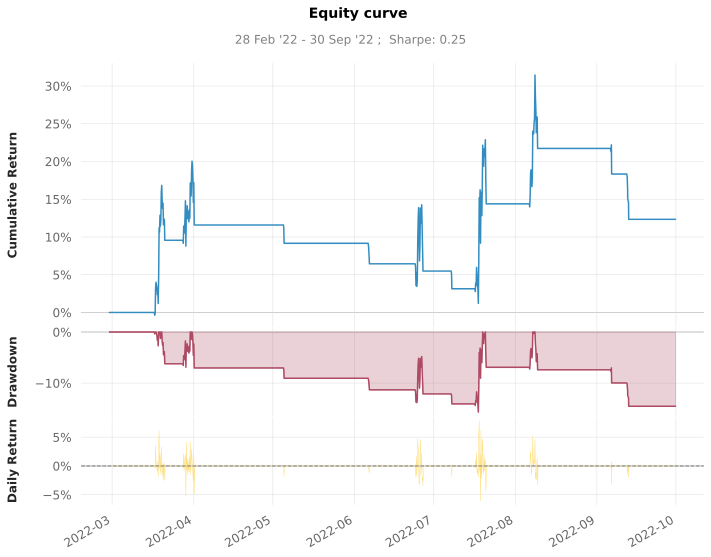

In [15]:
# Needed to improve the resolution of matplotlib chart used here
%config InlineBackend.figure_format = 'svg'

from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.visual.equity_curve import visualise_equity_curve

curve = calculate_equity_curve(state)
returns = calculate_returns(curve)
visualise_equity_curve(returns)

### Returns monthly breakdown

- Monthly returns
- Best day/week/month/year


2025-01-04 17:05:09,460 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,461 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,462 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,463 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,482 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,482 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,496 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,497 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.


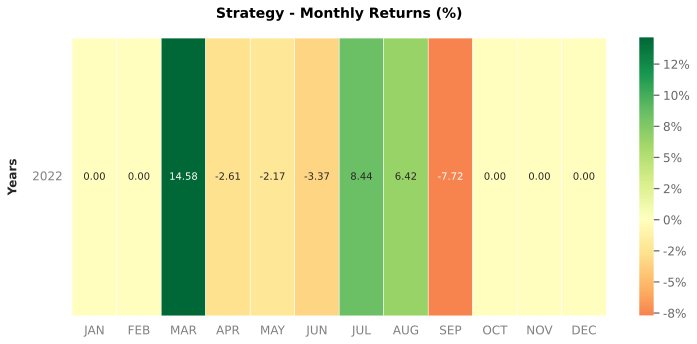

In [16]:
from tradeexecutor.visual.equity_curve import visualise_returns_over_time

visualise_returns_over_time(returns)

### Returns distribution

Show the difference between good and bad trading periods.

- Daily/montly/yearly

- Best/worst/avg.

2025-01-04 17:05:09,716 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,716 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,723 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,723 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,728 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,729 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,739 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.
2025-01-04 17:05:09,740 matplotlib.font_manager                            WARNING  findfont: Font family 'Arial' not found.


/home/anton/Documents/my-test/Trading/new-trading-view-strategy/tradingview-defi-strategy/.venv/lib/python3.11/site-packages/quantstats/_plotting/core.py:1016: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/home/anton/Documents/my-test/Trading/new-trading-view-strategy/tradingview-defi-strategy/.venv/lib/python3.11/site-packages/quantstats/_plotting/core.py:1018: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

/home/anton/Documents/my-test/Trading/new-trading-view-strategy/t

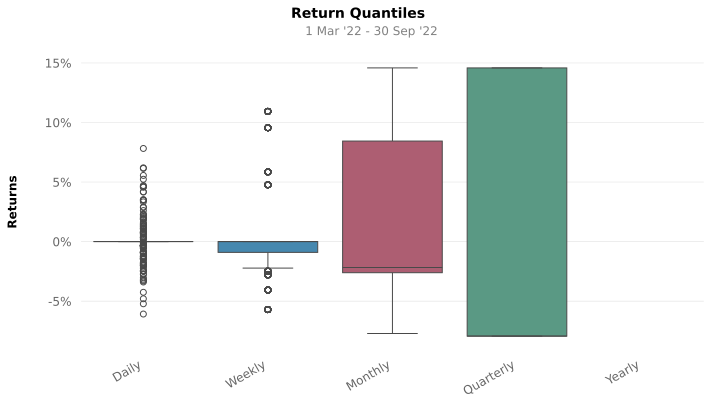

In [17]:
from tradeexecutor.visual.equity_curve import visualise_returns_distribution

visualise_returns_distribution(returns)

### Position chart

- Visualise individual positions over the price timeline

- Hover your mouse on the position marker circle to get its underlying details

- Positions closed for profit are marked green while losing ones are red

In [21]:
candles = universe.universe.candles.get_candles_by_pair(universe.get_single_pair().internal_id)

figure2 = visualise_single_pair_positions_with_duration_and_slippage(
    state,
    candles=candles,
    start_at=START_AT,
    end_at=END_AT,
    execution_context=executor
)

figure2.show()

### Benchmarks

Here we benchmark the strategy performance against some baseline scenarios.

- Buy and hold US dollar
- Buy and hold ETH


In [22]:
from tradeexecutor.visual.benchmark import visualise_benchmark

traded_pair = universe.universe.pairs.get_single()

fig = visualise_benchmark(
    "Bollinger bands example strategy",
    portfolio_statistics=state.stats.portfolio,
    all_cash=state.portfolio.get_initial_deposit(),
    buy_and_hold_asset_name=traded_pair.base_token_symbol,
    buy_and_hold_price_series=universe.universe.candles.get_single_pair_data()["close"],
    start_at=START_AT,
    end_at=END_AT,
    height=800
)

fig.show()

/tmp/ipykernel_420216/1786842740.py:8: DeprecationWarning:

This function is deprecated. Use get_initial_cash() instead

/tmp/ipykernel_420216/1786842740.py:5: DeprecationWarning:

This function is deprecated. Use visualise_equity_curve_benchmark instead



### Analyse trade statistics

Here we calculate statistics on how well the strategy performed.

- Won/lost trades
- Timeline of taken positions with color coding of trade performance


In [23]:
from tradeexecutor.analysis.trade_analyser import build_trade_analysis

analysis = build_trade_analysis(state.portfolio)

### Trade summary

Overview of strategy performance



In [24]:
from IPython.core.display_functions import display

summary = analysis.calculate_summary_statistics()

with pd.option_context("display.max_row", None):
    display(summary.to_dataframe())

,0
Trading period length,179 days 21 hours
Trading start,None
Trading end,None
Return %,12.34%
Annualised return %,25.03%
Cash at start,"$5,000.00"
Value at end,"$5,616.87"
Time in market,0.00%
Time in market volatile,0.00%
Trade volume,"$119,326.82"


### Position and trade timeline

Display all positions and how much profit they made.

In [25]:
from tradeexecutor.analysis.trade_analyser import expand_timeline

timeline = analysis.create_timeline()

expanded_timeline, apply_styles = expand_timeline(
        universe.universe.exchanges,
        universe.universe.pairs,
        timeline)

# Do not truncate the row output
with pd.option_context("display.max_row", None):
    display(apply_styles(expanded_timeline))


Remarks,Type,Opened at,Duration,Exchange,Base asset,Quote asset,Position max value,PnL USD,PnL %,Open mid price USD,Close mid price USD,Trade count,LP fees,Notes
,Long,2022-03-17,3 days 20 hours,Trader Joe,WAVAX,USDC,"$4,500.00",$478.18,10.63%,$76.605821,$84.746098,2,$18.98,
,Long,2022-03-28,4 days 4 hours,Trader Joe,WAVAX,USDC,"$4,930.36",$101.32,2.06%,$89.995709,$91.845209,2,$19.94,
SL,Long,2022-05-05,2 hours 45 mins,Trader Joe,WAVAX,USDC,"$5,021.55",$-121.28,-2.42%,$68.780592,$67.119392,2,$19.86,Stoploss:67.27043901488788 mid-price:67.25389958061416
SL,Long,2022-06-06,7 hours,Trader Joe,WAVAX,USDC,"$4,912.40",$-135.73,-2.76%,$27.190276,$26.438997,2,$19.40,Stoploss:26.59328406958558 mid-price:26.491980489499895
SL,Long,2022-06-24,3 hours 15 mins,Trader Joe,WAVAX,USDC,"$4,790.24",$-125.36,-2.62%,$19.607482,$19.094367,2,$18.93,Stoploss:19.176978824456953 mid-price:19.132632473480037
,Long,2022-06-24,2 days 16 hours,Trader Joe,WAVAX,USDC,"$4,677.42",$77.22,1.65%,$19.307837,$19.626590,2,$18.88,
SL,Long,2022-07-07,2 hours 45 mins,Trader Joe,WAVAX,USDC,"$4,746.92",$-117.32,-2.47%,$20.509074,$20.002181,2,$18.77,Stoploss:20.05877537668737 mid-price:20.042265744239323
,Long,2022-07-16,4 days 4 hours,Trader Joe,WAVAX,USDC,"$4,641.33",$562.61,12.12%,$21.019157,$23.567041,2,$19.71,
,Long,2022-08-06,3 days,Trader Joe,WAVAX,USDC,"$5,147.67",$366.93,7.13%,$25.490690,$27.307694,2,$21.35,
SL,Long,2022-09-06,6 hours 15 mins,Trader Joe,WAVAX,USDC,"$5,477.91",$-169.59,-3.10%,$20.068787,$19.447493,2,$21.59,Stoploss:19.62815500406794 mid-price:19.486465775469128


## Finishing notes

Print out a line to signal the notebook finished the execution successfully.

In [26]:
print("All ok")

All ok
